# Experiment 3 — Signals in a Geometric Brownian Motion

This notebook implements the three experiments of Chapter 3 of *Design of the Numerical Experiments*: the strength sweep (Experiment 3.1), the signal-quality study (Experiment 3.2), and the drift-oracle-versus-noisy comparison (Experiment 3.3).

The object under study is the signal–strength map
$$
w_i(\boldsymbol{s},\beta) \;=\; \frac{e^{\beta s_i}}{\sum_{j=1}^{N} e^{\beta s_j}},
$$
driven by prices simulated from geometric Brownian motion. The design constraint throughout is the **clean-versus-leakage line**: the signal is informative about the future without being the future. The diffusion shock $\phi_i$, which realises the price, never enters the signal.

## Model and simulation design

**One-step return (eq. 3.1).** Each stock follows $\mathrm{d}S_i = \mu_i S_i\,\mathrm{d}t + \sigma_i S_i\,\mathrm{d}W_i$. Over a single step of length $\Delta t$ the simple return is
$$
R_i \;=\; \exp\!\Big[\big(\mu_i - \tfrac{1}{2}\sigma_i^2\big)\Delta t + \sigma_i \sqrt{\Delta t}\,\phi_i\Big] - 1,
\qquad \phi_i \sim \mathcal{N}(0,1).
$$

**Clean signal (eq. 3.2).** The signal tracks the drift, not the realised return:
$$
s_i \;=\; \mu_i + \varepsilon_i, \qquad \varepsilon_i \sim \mathcal{N}(0,\sigma_\varepsilon^2), \qquad \varepsilon_i \perp (\mu_i,\phi_i) .
$$
Conditional on the latent drift $\mu_i$, each stock has two independent shocks: the signal noise $\varepsilon_i$ (drawn at $t=0$ when the view is formed) and the diffusion shock $\phi_i$ (which realises the price). Setting $\sigma_\varepsilon = 0$ gives the **drift-oracle** sweep $s_i = \mu_i$: perfect knowledge of expected drift, not of the realised return, because the diffusion shock remains unknown.

**Monte-Carlo algorithm (§3.3).** For each replication: draw drifts $\mu_i$, form signals, allocate by softmax, draw diffusion shocks, score $u(\boldsymbol{w}^\top \boldsymbol{R})$ with CARA utility $u(x) = -e^{-\gamma x}$, and average to estimate $\mathrm{EU}(\beta) = \mathbb{E}\,u(\boldsymbol{w}^\top\boldsymbol{R})$. There is deliberately no path, no rebalancing and no compounding: a single step isolates the structural effect of strength.

**Two implementation refinements** (they change the estimator, not the model):

1. *Common random numbers (CRN).* The same draws of $(\boldsymbol{\mu}, \boldsymbol{\varepsilon}, \boldsymbol{\phi})$ are reused at every point of the $\beta$ grid, and the same $(\boldsymbol{\mu}, \boldsymbol{\phi})$ across noise levels $\sigma_\varepsilon$ (only the scale of $\varepsilon$ changes). Differences between EU curves are then estimated on paired samples, so $\mathrm{EU}(\beta)$ is a smooth function of $\beta$ and the location of the maximiser $\beta^\star$ is not an artefact of independent Monte-Carlo noise at each grid point.
2. *Certainty-equivalent reporting.* Raw CARA values are negative and their scale depends on $\gamma$. All plots therefore report the certainty equivalent $\mathrm{CE}(\beta) = -\gamma^{-1}\ln(-\mathrm{EU}(\beta))$, in units of return, relative to the equal-weight baseline: $\Delta\mathrm{CE}(\beta) = \mathrm{CE}(\beta) - \mathrm{CE}(0)$. The maximiser is unchanged because the transform is monotone.

In [33]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# ---------------- parameters ----------------
N        = 20        # number of stocks
dt       = 1.0       # one step of one year
sigma    = 0.20      # diffusion volatility, common to all names
mu_bar   = 0.05      # cross-sectional mean of the drifts
sigma_mu = 0.05      # cross-sectional dispersion of the drifts
gamma    = 5.0       # CARA absolute risk aversion
n_sims   = 30_000    # Monte-Carlo replications

beta_grid = np.linspace(0.0, 120.0, 121)   # step 1; peaks sit around 1/sigma_mu = 20

# ---------------- common random numbers ----------------
# One set of draws shared by every beta and every sigma_eps.
mu   = mu_bar + sigma_mu * rng.standard_normal((n_sims, N))   # drifts, redrawn each replication
eps0 = rng.standard_normal((n_sims, N))                       # standardised signal noise
phi  = rng.standard_normal((n_sims, N))                       # diffusion shocks (never in the signal)

R = np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * phi) - 1.0


In [34]:
def softmax_weights(s, beta):
    # w_i = exp(beta s_i) / sum_j exp(beta s_j), computed stably row by row
    z = beta * s
    z -= z.max(axis=1, keepdims=True)          # invariance to additive shifts
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def eu_curve(sigma_eps, beta_grid=beta_grid):
    # Estimate EU(beta) and its MC standard error on the common draws.
    # Returns (EU, SE, CE) as arrays over the beta grid.
    s = mu + sigma_eps * eps0                  # clean signal: eps ⟂ phi by construction
    EU = np.empty(len(beta_grid))
    SE = np.empty(len(beta_grid))
    for k, b in enumerate(beta_grid):
        w = softmax_weights(s, b)
        port = (w * R).sum(axis=1)
        u = -np.exp(-gamma * port)
        EU[k] = u.mean()
        SE[k] = u.std(ddof=1) / np.sqrt(n_sims)
    CE = -np.log(-EU) / gamma
    return EU, SE, CE

def beta_star(beta_grid, CE):
    k = int(np.argmax(CE))
    return beta_grid[k], CE[k], k


## Experiment 3.1 — Strength sweep

Sweep $\beta$ from $0$ upward and plot $\mathrm{EU}(\beta)$ (as $\Delta\mathrm{CE}$) relative to the $\beta=0$ equal-weight baseline. The question is whether $\mathrm{EU}(\beta)$ is monotone — utility always rising with a harder tilt — or whether an interior maximiser $\beta^\star$ exists, beyond which the concentration risk outweighs the gain from tilting on the signal.

The mechanism pulling in each direction: a larger $\beta$ moves weight towards names with high scores, which raises the expected portfolio return when the score is informative about the drift; but it also destroys diversification, and the CARA investor pays for the extra variance. If the two forces cross, $\beta^\star$ is finite and interior.

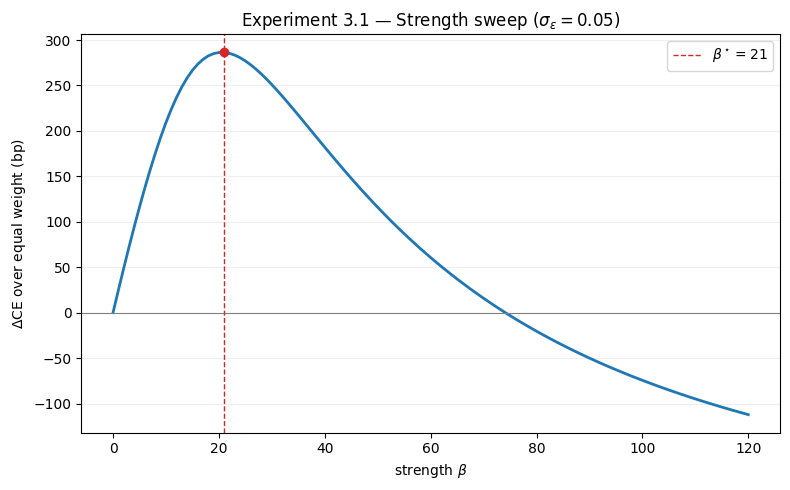

beta* = 21.0
CE gain at beta*: 286.3 bp over equal weight
Paired MC SE of the CE gain: 4.7 bp


In [35]:
sigma_eps_base = 0.05   # baseline signal noise, comparable to the drift dispersion

EU_b, SE_b, CE_b = eu_curve(sigma_eps_base)
bstar, ce_at_bstar, k = beta_star(beta_grid, CE_b)
dCE_b = CE_b - CE_b[0]

# Paired delta-method SE for Delta CE at the selected grid optimum.
s_base = mu + sigma_eps_base * eps0
p_0 = (softmax_weights(s_base, 0.0) * R).sum(axis=1)
p_star = (softmax_weights(s_base, bstar) * R).sum(axis=1)
u_0 = -np.exp(-gamma * p_0)
u_star = -np.exp(-gamma * p_star)
g_0 = -1.0 / (gamma * EU_b[0])
g_star = -1.0 / (gamma * EU_b[k])
influence = g_star * (u_star - EU_b[k]) - g_0 * (u_0 - EU_b[0])
se_dCE = influence.std(ddof=1) / np.sqrt(n_sims)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(beta_grid, 1e4 * dCE_b, lw=2)
ax.axhline(0, color='grey', lw=0.8)
ax.axvline(bstar, color='tab:red', ls='--', lw=1,
           label=fr'$\beta^\star = {bstar:.0f}$')
ax.scatter([bstar], [1e4 * dCE_b[k]], color='tab:red', zorder=5)
ax.set_xlabel(r'strength $\beta$')
ax.set_ylabel(r'$\Delta$CE over equal weight (bp)')
ax.set_title(fr'Experiment 3.1 — Strength sweep ($\sigma_\varepsilon = {sigma_eps_base}$)')
ax.grid(axis='y', alpha=0.2)
ax.legend()
plt.tight_layout(); plt.show()

print(f"beta* = {bstar:.1f}")
print(f"CE gain at beta*: {1e4*dCE_b[k]:.1f} bp over equal weight")
print(f"Paired MC SE of the CE gain: {1e4*se_dCE:.1f} bp")


**Reading.** The curve rises from the equal-weight baseline, peaks at an interior $\beta^\star$, and then falls as the portfolio concentrates towards the single-best-score name. $\mathrm{EU}(\beta)$ is not monotone: there is a limit on how hard the signal should be acted upon, and $\beta^\star$ is the strength at which the marginal gain from tilting is exactly balanced by the marginal cost of concentration. This is the finite-strength conclusion Experiment 1 motivated from the estimation-error side, reproduced here in a setting where the signal noise is controlled explicitly.

### The optimum in P&L terms

The certainty equivalent selects $\beta^\star$, but it is worth seeing what that optimum looks like in raw profit-and-loss. Because the simulation uses common random numbers, the tilted portfolio and the equal-weight baseline face *identical* draws of $(\boldsymbol{\mu}, \boldsymbol{\varepsilon}, \boldsymbol{\phi})$ in every replication, so the paired difference
$$
D \;=\; \boldsymbol{w}(\beta^\star)^\top \boldsymbol{R} \;-\; \boldsymbol{w}(0)^\top \boldsymbol{R}
$$
isolates the allocation effect of the tilt, replication by replication, while controlling for the identical market realisation faced by both portfolios. (Under GBM a common drift shift scales gross returns, so it is not literally cancelled by subtraction.) Two views are reported:

* a **summary table** at $\beta \in \{0, \beta^\star, 3\beta^\star\}$ — mean return, volatility, probability of loss, the 5% return quantile, the probability of beating equal weight, and $\Delta$CE;
* the **distribution of the paired relative return** $D$ at $\beta^\star$.

One caution on reading these: in this Gaussian signal model, and over the simulated grid, mean return increases with $\beta$ because higher scores imply higher conditional expected returns. Selecting on mean return alone would therefore favour the hardest available tilt. The table shows the mechanism instead: the mean keeps rising past $\beta^\star$ while the downside (loss probability and 5% quantile) deteriorates faster, which is precisely the trade the CARA investor refuses. The return view explains the CE optimum; it does not replace it.

  beta     mean      vol  P(loss) 5%quantile  P(beat 1/N)  dCE (bp)
     0    5.28%    4.91%    14.0%   -2.63%           --       0.0
    21    9.93%   10.26%    14.9%   -4.90%        70.6%     286.3
    63   12.15%   18.18%    25.3%  -14.15%        63.6%      46.2


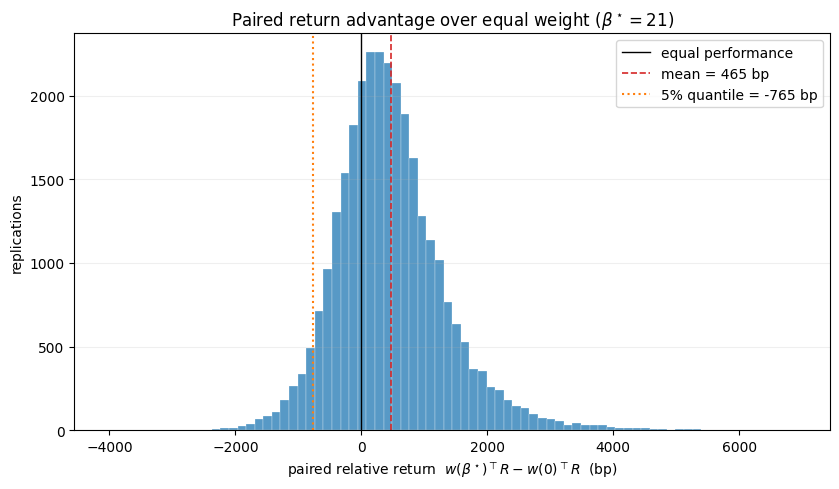

P(tilt beats 1/N) = 70.6%
mean relative return = 465 bp,  5% quantile = -765 bp


In [37]:
# ---- P&L view of the CE optimum (paired against equal weight) ----
betas_show = [0.0, bstar, 3 * bstar]

ports, rows = {}, []
for b in betas_show:
    w = softmax_weights(s_base, b)
    p = (w * R).sum(axis=1)
    ports[b] = p
    u = -np.exp(-gamma * p)
    ce = -np.log(-u.mean()) / gamma
    rows.append((b, p.mean(), p.std(ddof=1), (p < 0).mean(),
                 np.quantile(p, 0.05),
                 (p > ports[0.0]).mean() if b > 0 else np.nan,
                 1e4 * (ce - CE_b[0])))

print(f"{'beta':>6} {'mean':>8} {'vol':>8} {'P(loss)':>8} {'5%quantile':>8} {'P(beat 1/N)':>12} {'dCE (bp)':>9}")
for b, m, v, pl, q5, pb, dce in rows:
    pb_s = '          --' if np.isnan(pb) else f'{pb:>12.1%}'
    print(f"{b:>6.0f} {m:>8.2%} {v:>8.2%} {pl:>8.1%} {q5:>8.2%} {pb_s} {dce:>9.1f}")

# Paired relative return at beta*: both portfolios face the same simulated state.
d = ports[bstar] - ports[0.0]
q05_d = np.quantile(d, 0.05)

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.hist(1e4 * d, bins=80, color='tab:blue', alpha=0.75, edgecolor='white', linewidth=0.25)
ax.axvline(0, color='black', lw=1.0, label='equal performance')
ax.axvline(1e4 * d.mean(), color='tab:red', ls='--', lw=1.2,
           label=fr'mean = {1e4 * d.mean():.0f} bp')
ax.axvline(1e4 * q05_d, color='tab:orange', ls=':', lw=1.5,
           label=fr'5% quantile = {1e4 * q05_d:.0f} bp')
ax.set_xlabel(r'paired relative return  $w(\beta^\star)^\top R - w(0)^\top R$  (bp)')
ax.set_ylabel('replications')
ax.set_title(fr'Paired return advantage over equal weight ($\beta^\star = {bstar:.0f}$)')
ax.grid(axis='y', alpha=0.2)
ax.legend()
plt.tight_layout(); plt.show()

print(f"P(tilt beats 1/N) = {(d > 0).mean():.1%}")
print(f"mean relative return = {1e4 * d.mean():.0f} bp,  5% quantile = {1e4 * q05_d:.0f} bp")

## Experiment 3.2 — Signal quality

Vary the signal-noise standard deviation $\sigma_\varepsilon$ (clean / medium / noisy) and track $\beta^\star$. Prediction: the noisier the signal, the smaller $\beta^\star$, tending to $\beta^\star \to 0$ as $\sigma_\varepsilon \to \infty$.

A heuristic sharpens the prediction. Given the Gaussian structure, the posterior mean of the drift given the signal is a shrinkage of $s_i$ towards the grand mean:
$$
\mathbb{E}[\mu_i \mid s_i] \;=\; \bar{\mu} + \kappa\,(s_i - \bar{\mu}),
\qquad
\kappa \;=\; \frac{\sigma_\mu^2}{\sigma_\mu^2 + \sigma_\varepsilon^2}.
$$
Because the softmax is invariant to adding a constant to all scores, acting on the posterior mean with strength $\beta$ is the same as acting on $s$ with effective strength $\beta\kappa$. If the investor's optimal strength on a *perfect* drift reading is $\beta^\star_{\mathrm{drift}}$, the Bayesian benchmark for a noisy signal is
$$
\beta^\star(\sigma_\varepsilon) \;\approx\; \beta^\star_{\mathrm{drift}} \cdot \frac{\sigma_\mu^2}{\sigma_\mu^2 + \sigma_\varepsilon^2},
$$
which the simulation can be checked against. This is a heuristic (the oracle strength itself need not be exactly invariant), but it turns the qualitative prediction "noise pulls $\beta^\star$ back" into a quantitative one at no extra cost.

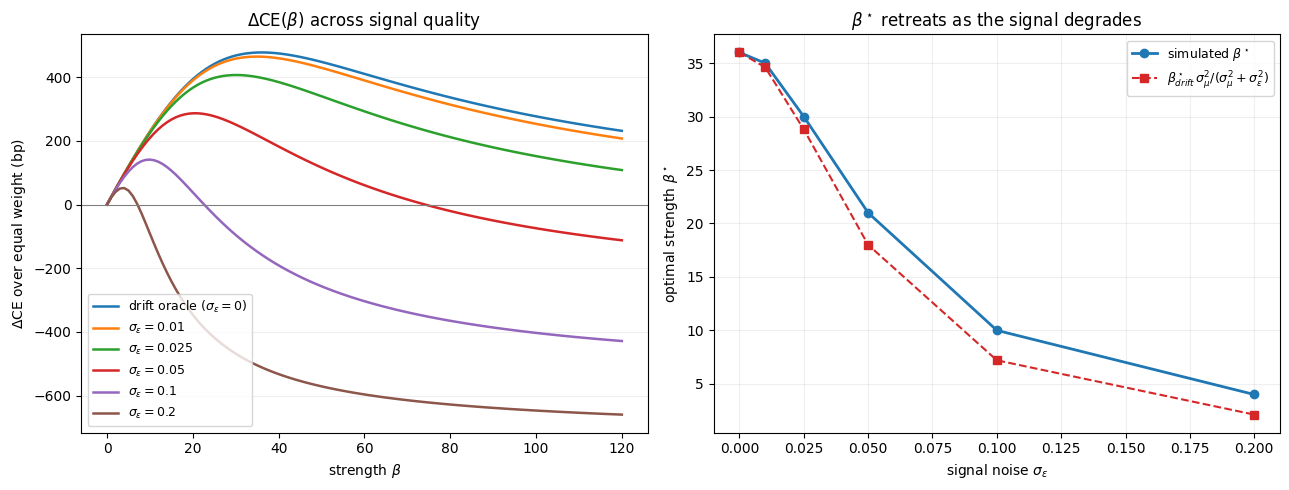

 sigma_eps    beta*  shrinkage pred.  peak dCE (bp)
       0.0       36               36          477.3
      0.01       35               35          464.3
     0.025       30               29          406.4
      0.05       21               18          286.3
       0.1       10                7          141.0
       0.2        4                2           51.8


In [31]:
sigma_eps_levels = [0.0, 0.01, 0.025, 0.05, 0.10, 0.20]
results = {}
for se in sigma_eps_levels:
    EU, SE, CE = eu_curve(se)
    results[se] = (EU, SE, CE)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for se in sigma_eps_levels:
    _, _, CE = results[se]
    label = 'drift oracle ($\\sigma_\\varepsilon=0$)' if se == 0 else fr'$\sigma_\varepsilon={se}$'
    ax.plot(beta_grid, 1e4 * (CE - CE[0]), lw=1.8, label=label)
ax.axhline(0, color='grey', lw=0.8)
ax.set_xlabel(r'strength $\beta$')
ax.set_ylabel(r'$\Delta$CE over equal weight (bp)')
ax.set_title(r'$\Delta$CE$(\beta)$ across signal quality')
ax.grid(axis='y', alpha=0.2)
ax.legend(fontsize=9)

bstars = np.array([beta_star(beta_grid, results[se][2])[0] for se in sigma_eps_levels])
kappa  = sigma_mu**2 / (sigma_mu**2 + np.array(sigma_eps_levels)**2)
pred   = bstars[0] * kappa   # Bayesian shrinkage benchmark anchored at the drift oracle

ax = axes[1]
ax.plot(sigma_eps_levels, bstars, 'o-', lw=2, label=r'simulated $\beta^\star$')
ax.plot(sigma_eps_levels, pred, 's--', lw=1.5, color='tab:red',
        label=r'$\beta^\star_{drift}\,\sigma_\mu^2/(\sigma_\mu^2+\sigma_\varepsilon^2)$')
ax.set_xlabel(r'signal noise $\sigma_\varepsilon$')
ax.set_ylabel(r'optimal strength $\beta^\star$')
ax.set_title(r'$\beta^\star$ retreats as the signal degrades')
ax.grid(alpha=0.2)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"{'sigma_eps':>10} {'beta*':>8} {'shrinkage pred.':>16} {'peak dCE (bp)':>14}")
for se, bs, pr in zip(sigma_eps_levels, bstars, pred):
    CE = results[se][2]
    print(f"{se:>10} {bs:>8.0f} {pr:>16.0f} {1e4*(CE.max()-CE[0]):>14.1f}")


**Reading.** Both predictions are borne out. The peak of each curve moves left and down as $\sigma_\varepsilon$ grows: a noisier signal earns less at its own optimum *and* commands a smaller optimal strength, with $\beta^\star \to 0$ as the signal becomes pure noise. The simulated $\beta^\star(\sigma_\varepsilon)$ follows the Bayesian shrinkage benchmark qualitatively and is close at low-to-moderate noise levels. This supports interpreting the optimal strength as increasing with statistical reliability. It does not identify $\beta$ with precision itself, because $\beta^\star$ also depends on risk aversion, return volatility and the scale of the signal.

## Experiment 3.3 — Drift oracle versus noisy

Overlay the drift-oracle sweep ($s_i = \mu_i$) and a noisy sweep ($s_i = \mu_i + \varepsilon_i$). Two distinct gaps separate their optima:

* the **vertical gap** — utility lost at the optimum because the signal is corrupted rather than perfect: the cost of signal noise;
* the **horizontal gap** — the pull-back of the optimal strength itself: with a clean drift a high signal really is a high drift and one can bet hard; with noise, a large $s_i$ may be a lucky draw of $\varepsilon_i$, so the tilt must be more cautious.

Separating the two confirms that noise both lowers the achievable utility and forces a more conservative strength; these are two effects, not one.

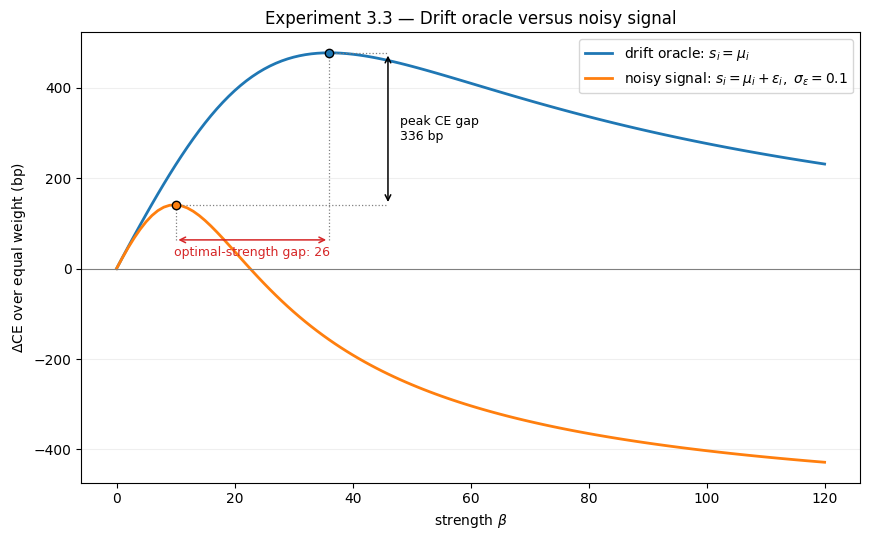

drift oracle: beta* = 36, peak gain = 477.3 bp
noisy signal: beta* = 10, peak gain = 141.0 bp
peak CE gap (cost of noise at the two optima) = 336.3 bp
optimal-strength gap = 26


In [32]:
se_noisy = 0.10
_, _, CE_or = results[0.0]
_, _, CE_no = results[se_noisy]
d_or, d_no = 1e4 * (CE_or - CE_or[0]), 1e4 * (CE_no - CE_no[0])

b_or, _, k_or = beta_star(beta_grid, CE_or)
b_no, _, k_no = beta_star(beta_grid, CE_no)

fig, ax = plt.subplots(figsize=(8.8, 5.5))
oracle_color, noisy_color = 'tab:blue', 'tab:orange'
ax.plot(beta_grid, d_or, lw=2, color=oracle_color, label=r'drift oracle: $s_i=\mu_i$')
ax.plot(beta_grid, d_no, lw=2, color=noisy_color,
        label=fr'noisy signal: $s_i=\mu_i+\varepsilon_i,\ \sigma_\varepsilon={se_noisy}$')
ax.axhline(0, color='grey', lw=0.8)
ax.scatter(b_or, d_or[k_or], color=oracle_color, edgecolor='black', zorder=5)
ax.scatter(b_no, d_no[k_no], color=noisy_color, edgecolor='black', zorder=5)

# Vertical bracket compares the two maximum CE gains. Horizontal guides make
# clear that these values occur at different strengths.
x_gap = b_or + 10
ax.hlines(d_or[k_or], b_or, x_gap, colors='grey', linestyles=':', lw=0.9)
ax.hlines(d_no[k_no], b_no, x_gap, colors='grey', linestyles=':', lw=0.9)
ax.annotate('', xy=(x_gap, d_no[k_no]), xytext=(x_gap, d_or[k_or]),
            arrowprops=dict(arrowstyle='<->', color='black', lw=1.1))
ax.text(x_gap + 2, 0.5 * (d_no[k_no] + d_or[k_or]),
        f'peak CE gap\n{d_or[k_or] - d_no[k_no]:.0f} bp', va='center', fontsize=9)

# Horizontal bracket compares the locations of the two optima.
y_gap = 0.45 * d_no[k_no]
ax.vlines([b_no, b_or], y_gap, [d_no[k_no], d_or[k_or]],
          colors='grey', linestyles=':', lw=0.9)
ax.annotate('', xy=(b_or, y_gap), xytext=(b_no, y_gap),
            arrowprops=dict(arrowstyle='<->', color='tab:red', lw=1.1))
ax.text(0.5 * (b_or + b_no), y_gap - 35,
        fr'optimal-strength gap: {b_or - b_no:.0f}',
        fontsize=9, ha='center', color='tab:red')
ax.set_xlabel(r'strength $\beta$')
ax.set_ylabel(r'$\Delta$CE over equal weight (bp)')
ax.set_title('Experiment 3.3 — Drift oracle versus noisy signal')
ax.grid(axis='y', alpha=0.2)
ax.legend()
plt.tight_layout(); plt.show()

print(f"drift oracle: beta* = {b_or:.0f}, peak gain = {d_or[k_or]:.1f} bp")
print(f"noisy signal: beta* = {b_no:.0f}, peak gain = {d_no[k_no]:.1f} bp")
print(f"peak CE gap (cost of noise at the two optima) = {d_or[k_or]-d_no[k_no]:.1f} bp")
print(f"optimal-strength gap = {b_or-b_no:.0f}")


## Methodological notes

**Scale of $\beta$.** The signal lives on the scale of annual drifts (a few percent), so $\beta$ must reach the order of $1/\sigma_\mu = 20$ before $\beta\,\Delta s$ is of order one and weights differentiate; the observed $\beta^\star$ sits exactly there. The numbers on the $\beta$ axis are therefore not comparable to the $\beta \in \{0,1,3\}$ of the Chapter 2 illustration, where the scores were of order one. If comparability across chapters matters, standardise the signal cross-sectionally; this was not done here so that $\beta$ keeps the same meaning across all values of $\sigma_\varepsilon$ (standardising would rescale the signal by its own noise level and mix the two dials).

**Drifts are redrawn each replication.** Step 1 of the algorithm draws $\mu_i$ fresh every replication, so EU averages over cross-sections of drifts rather than conditioning on one particular cross-section. The estimates are statements about the structure of the map, not about a fixed set of names.

**Monte-Carlo error.** Conditional on the common random-number sample, the plotted curve is smooth in $\beta$; this reduces the simulation noise in comparisons between nearby grid points but does not eliminate sampling uncertainty. The reported uncertainty for Experiment 3.1 is therefore the paired delta-method standard error of $\Delta\mathrm{CE}(\beta^\star)$, expressed in the same basis-point units as the estimated gain. Because $\beta^\star$ is selected on a grid with step one, its reported value also has grid-resolution error.

**CARA and GBM returns.** One-step GBM gross returns $1+R_i$ are lognormal, so simple returns $R_i$ are shifted-lognormal, right-skewed and non-elliptical. The CARA expected utility computed here therefore sees distributional features that a mean–variance summary would discard. This is deliberate: the simulation scores portfolios under the stated preference, and any gap between the CARA optimum and a two-moment approximation is part of what Chapter 4's map comparison can pick up.

**One design caution for Experiment 3.2.** Because $\varepsilon = \sigma_\varepsilon \cdot \varepsilon_0$ reuses the same standardised draws $\varepsilon_0$ at every noise level, differences across $\sigma_\varepsilon$ are also paired comparisons; the curves in the left panel move smoothly with $\sigma_\varepsilon$ for the same reason the individual curves are smooth in $\beta$.